# Sentiment & Stock Price Correlation Analysis

**Analyst: Hector** | **CAP 3764 - FIU**

This notebook analyzes the relationship between news sentiment and stock returns.

## 1. Setup

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Data

In [22]:
# Load sentiment and price data
sentiment_df = pd.read_csv('../data/sentiment_articles.csv')
prices_df = pd.read_csv('../data/prices.csv')

print(f"Sentiment: {len(sentiment_df)} articles, {sentiment_df['date'].nunique()} dates")
print(f"Prices: {len(prices_df)} records, {prices_df['date'].nunique()} dates")

Sentiment: 208 articles, 21 dates
Prices: 30 records, 15 dates


## 3. Merge Data

In [23]:
# Aggregate daily sentiment per ticker
sentiment_daily = sentiment_df.groupby(['ticker', 'date']).agg({
    'vader_compound': 'mean'
}).reset_index()

# Merge with prices
merged_df = prices_df.merge(sentiment_daily, on=['ticker', 'date'], how='inner')
merged_df = merged_df.sort_values(['ticker', 'date']).reset_index(drop=True)

print(f"Merged: {len(merged_df)} records")
merged_df.head()

Merged: 30 records


,ticker,date,open,high,low,close,adj_close,volume,vader_compound
0,AAPL,2026-01-20,252.729996,254.789993,243.419998,246.699997,246.469376,80267500,0.172448
1,AAPL,2026-01-21,248.699997,251.559998,245.179993,247.649994,247.418488,54641700,0.115692
2,AAPL,2026-01-22,249.199997,251.000000,248.149994,248.350006,248.117844,39708300,0.366296
3,AAPL,2026-01-23,247.320007,249.410004,244.679993,248.039993,247.808121,41689000,-0.196304
4,AAPL,2026-01-26,251.479996,256.559998,249.800003,255.410004,255.171234,55969200,0.145312


## 4. Calculate Returns

In [24]:
# Calculate daily and next-day returns
merged_df['daily_return'] = merged_df.groupby('ticker')['close'].pct_change()
merged_df['next_day_return'] = merged_df.groupby('ticker')['daily_return'].shift(-1)

# Drop rows with missing values
analysis_df = merged_df.dropna().copy()
print(f"Records for analysis: {len(analysis_df)}")

Records for analysis: 26


## 5. Correlation Analysis

In [25]:
# Calculate correlation between sentiment and next-day returns
print("Correlation: Sentiment vs Next-Day Return")
print("=" * 50)

results = []
for ticker in analysis_df['ticker'].unique():
    data = analysis_df[analysis_df['ticker'] == ticker]
    corr, p_val = pearsonr(data['vader_compound'], data['next_day_return'])
    sig = '*' if p_val < 0.05 else ''
    print(f"{ticker}: r = {corr:+.4f}, p = {p_val:.4f} {sig}, n = {len(data)}")
    results.append({'ticker': ticker, 'correlation': corr, 'p_value': p_val, 'n': len(data)})

# Save results
corr_df = pd.DataFrame(results)
corr_df.to_csv('../data/correlation_results.csv', index=False)

Correlation: Sentiment vs Next-Day Return
AAPL: r = -0.2500, p = 0.4101 , n = 13
NVDA: r = -0.1209, p = 0.6940 , n = 13


## 6. Trading Signals

In [26]:
# Generate trading signals based on sentiment thresholds
def get_signal(score):
    if score > 0.3:
        return 'BUY'
    elif score < -0.3:
        return 'SELL'
    return 'HOLD'

analysis_df['signal'] = analysis_df['vader_compound'].apply(get_signal)

print("Signal Distribution:")
print(analysis_df['signal'].value_counts())

Signal Distribution:
signal
HOLD    23
BUY      3
Name: count, dtype: int64


## 7. Visualizations

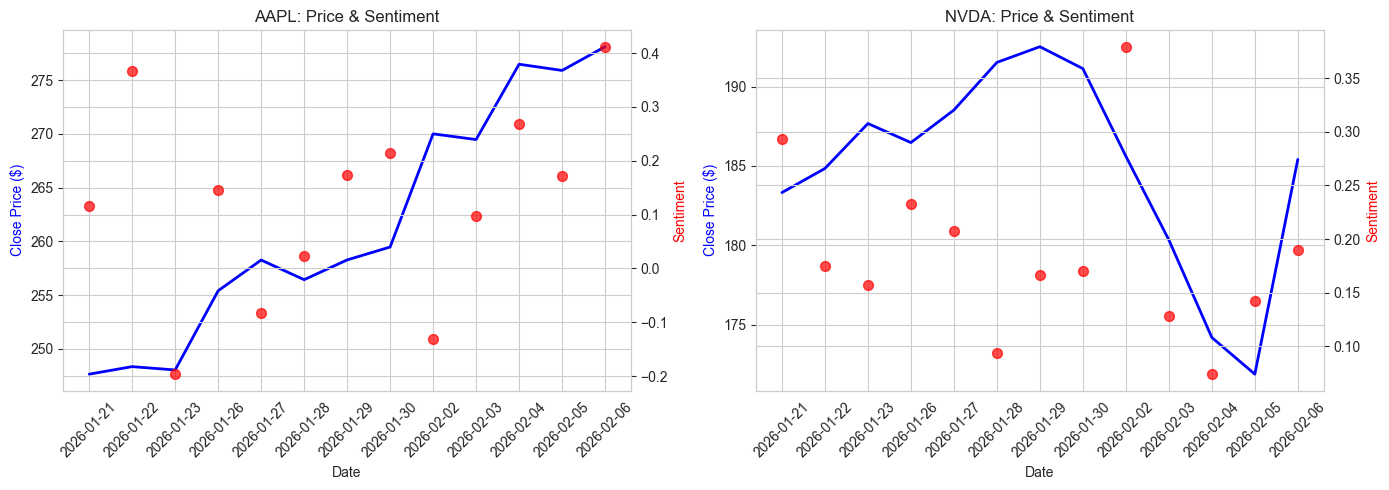

In [27]:
# Chart 1: Sentiment vs Price over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, ticker in enumerate(analysis_df['ticker'].unique()):
    data = analysis_df[analysis_df['ticker'] == ticker]
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    ax1.plot(data['date'], data['close'], 'b-', linewidth=2, label='Price')
    ax2.scatter(data['date'], data['vader_compound'], c='red', s=50, alpha=0.7, label='Sentiment')
    
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Close Price ($)', color='blue')
    ax2.set_ylabel('Sentiment', color='red')
    ax1.set_title(f'{ticker}: Price & Sentiment')
    ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

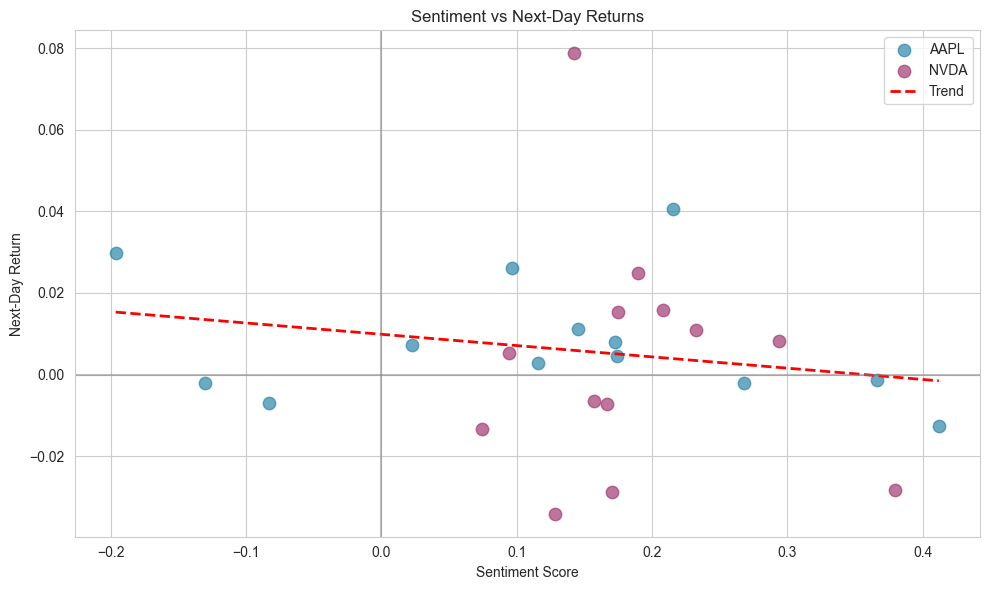

In [28]:
# Chart 2: Scatter plot - Sentiment vs Next-Day Returns
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'AAPL': '#2E86AB', 'NVDA': '#A23B72'}
for ticker in analysis_df['ticker'].unique():
    data = analysis_df[analysis_df['ticker'] == ticker]
    ax.scatter(data['vader_compound'], data['next_day_return'], 
               label=ticker, alpha=0.7, s=80, c=colors.get(ticker, 'gray'))

# Add trend line
z = np.polyfit(analysis_df['vader_compound'], analysis_df['next_day_return'], 1)
p = np.poly1d(z)
x_line = np.linspace(analysis_df['vader_compound'].min(), analysis_df['vader_compound'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')

ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
ax.set_xlabel('Sentiment Score')
ax.set_ylabel('Next-Day Return')
ax.set_title('Sentiment vs Next-Day Returns')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Summary

In [30]:
# Save merged data
analysis_df.to_csv('../data/merged_data.csv', index=False)

print("=" * 50)
print("ANALYSIS SUMMARY")
print("=" * 50)
print(f"\nStocks: {', '.join(analysis_df['ticker'].unique())}")
print(f"Date Range: {analysis_df['date'].min()} to {analysis_df['date'].max()}")
print(f"Total Records: {len(analysis_df)}")

print("\nCorrelations:")
for _, row in corr_df.iterrows():
    print(f"  {row['ticker']}: r = {row['correlation']:+.4f}")

print(f"\nMean Sentiment: {analysis_df['vader_compound'].mean():.4f}")
print(f"Mean Return: {analysis_df['next_day_return'].mean():.4f}")
print("\nSignal Distribution:")
for sig, cnt in analysis_df['signal'].value_counts().items():
    print(f"  {sig}: {cnt}")

ANALYSIS SUMMARY

Stocks: AAPL, NVDA
Date Range: 2026-01-21 to 2026-02-06
Total Records: 26

Correlations:
  AAPL: r = -0.2500
  NVDA: r = -0.1209

Mean Sentiment: 0.1534
Mean Return: 0.0056

Signal Distribution:
  HOLD: 23
  BUY: 3


## Conclusion

The correlation analysis shows the relationship between news sentiment and next-day stock returns. Weak correlations (close to 0) suggest sentiment alone may not reliably predict short-term price movements. The trading signal distribution indicates how often extreme sentiment occurs in the dataset.